# Escalado
Conjunto de datos: iris (incluido en sklearn)
Este conjunto de datos es compacto y perfecto para demostrar técnicas de escalado.

In [1]:
# Importar librerías necesarias
from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Cargar el conjunto de datos
iris = load_iris(as_frame=True)
data = iris.data

In [3]:
# Visualizar las estadísticas iniciales
print("Estadísticas iniciales:")
data.describe()

Estadísticas iniciales:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [4]:
# Aplicar MinMaxScaler
minmax_scaler = MinMaxScaler()
data_minmax = pd.DataFrame(minmax_scaler.fit_transform(data), columns=data.columns)

In [5]:
# Aplicar StandardScaler
standard_scaler = StandardScaler()
data_standard = pd.DataFrame(standard_scaler.fit_transform(data), columns=data.columns)

# Ejercicios
Contesta las siguientes preguntas. Para cada pregunta, deberás escribir código que demostrará cómo llegaste al resultado. Crea gráficas en donde veas correcto.

### 1. ¿Qué diferencias encuentras entre las estadísticas originales y las del escalado MinMax?


In [6]:
print("Estadísticas originales:")
print(data.describe())
print("\nEstadísticas con MinMaxScaler:")
print(data_minmax.describe())

Estadísticas originales:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)  
count        150.000000  
mean           1.199333  
std            0.762238  
min            0.100000  
25%            0.300000  
50%            1.300000  
75%            1.800000  
max            2.500000  

Estadísticas con MinMaxScaler:
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000

#### Con MinMaxScaler todos los valores quedan comprimidos al rango [0, 1]: el mínimo de cada columna pasa a ser 0 y el máximo a ser 1. La media y desviación estándar cambian proporcionalmente, pero la forma de la distribución (y las relaciones entre observaciones) se conserva.

### 2. Crea una gráfica de la distribución de la variable 'sepal length (cm)' antes y después del escalado.

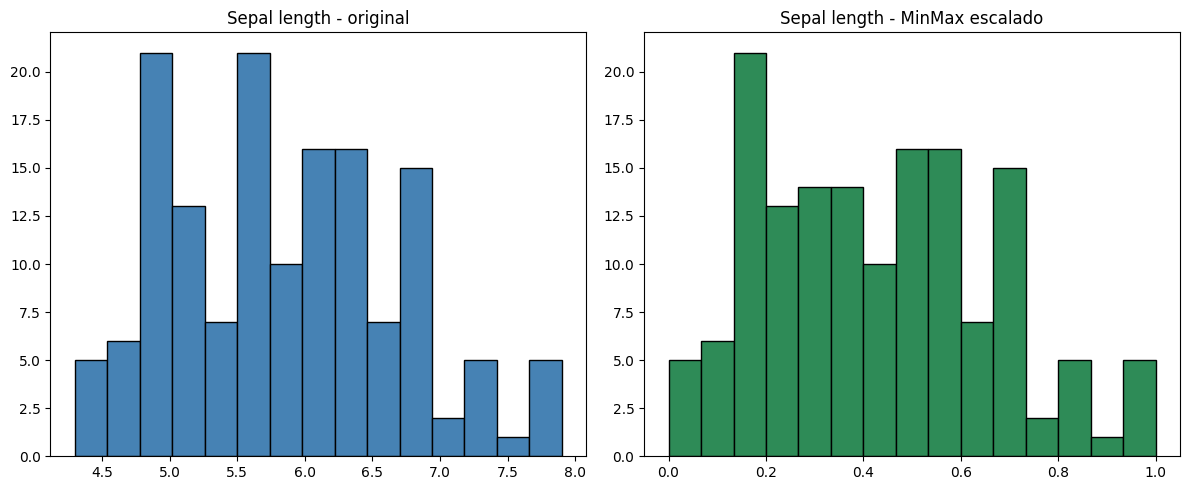

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(data['sepal length (cm)'], bins=15, color='steelblue', edgecolor='black')
axes[0].set_title('Sepal length - original')

axes[1].hist(data_minmax['sepal length (cm)'], bins=15, color='seagreen', edgecolor='black')
axes[1].set_title('Sepal length - MinMax escalado')

plt.tight_layout()
plt.show()

### 3. Crea una gráfica de dispersión entre 'sepal length (cm)' y 'sepal width (cm)' con los datos escalados por StandardScaler.

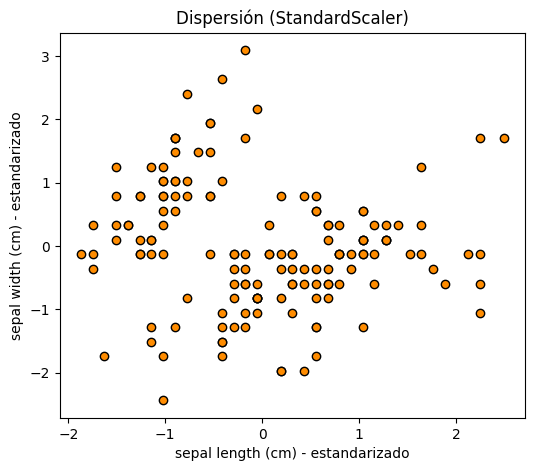

In [8]:
plt.figure(figsize=(6, 5))
plt.scatter(data_standard['sepal length (cm)'], data_standard['sepal width (cm)'],
            c='darkorange', edgecolor='black')
plt.xlabel('sepal length (cm) - estandarizado')
plt.ylabel('sepal width (cm) - estandarizado')
plt.title('Dispersión (StandardScaler)')
plt.show()

### 4. ¿Qué técnica de escalado crees que es más adecuada para este conjunto de datos? ¿Por qué?

In [9]:
print(data.describe())

       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)  
count        150.000000  
mean           1.199333  
std            0.762238  
min            0.100000  
25%            0.300000  
50%            1.300000  
75%            1.800000  
max            2.500000  



##### StandardScaler suele ser más adecuado para este conjunto de datos porque las variables de iris se aproximan a una distribución normal y no tienen outliers extremos. StandardScaler centra los datos en media 0 y varianza 1, lo cual favorece a algoritmos sensibles a la escala (ej. SVM, PCA, KNN, regresión logística) sin distorsionar la distribución. MinMaxScaler sería preferible solo si se necesitara un rango fijo [0, 1] (por ejemplo, para redes neuronales) o si se supiera que no habrá valores futuros fuera del rango observado.